# Task 2

In this task you will be provided a model that was pretrained on [BigEarthNet](https://bigearth.net) for pixel-wise classification (i.e. semantic segmentation). We will provide you with a checkpoint as well as the model definition and your task is to load that model using these weights and finetune it on our target domain (forest segmentation) in our target location (Amazon Rainforest). For that we will provide you with a finetuning dataset, which is based on [https://www.kaggle.com/datasets/akhilchibber/deforestation-detection-dataset](https://www.kaggle.com/datasets/akhilchibber/deforestation-detection-dataset).


<p align="center">
<img align="center" src="../../../images/Tile_Example.png" width="600"/>
</p>


The goals of this task are as follows:
1. Load a pretrained pixel-wise segmentation model
2. Adapt and finetune a baseline FCN decoder on a new domain (forest segmentation) and location (Amazon Rain Forest)
3. Implement an improved decoder with skip connections and compare both models quantitatively and qualitatively

## Imports

These are all imports we used when solving the task. Please leave them as is even though you might not need all of them.

In [1]:
import os
import rootutils
root = rootutils.setup_root(os.path.abspath(''), dotenv=True, pythonpath=True, cwd=False)

data_path = root / "data"
data_path.mkdir(exist_ok=True)
output_dir = root / "output"
output_dir.mkdir(exist_ok=True)

import torch
from types import SimpleNamespace
from huggingface_hub import PyTorchModelHubMixin
import lightning as L
from configilm import ConfigILM
from torchinfo import summary
import numpy as np
from pathlib import Path

# from torchmetrics.segmentation import MeanIoU
from torchmetrics.classification import MulticlassJaccardIndex
import torch.nn as nn
import torch.nn.functional as F

import lmdb
from torch.utils.data import Dataset, DataLoader, random_split
from safetensors.numpy import load as load_np_safetensor
import torchvision.transforms as transforms

from lightning.pytorch.callbacks import EarlyStopping, ModelCheckpoint
from lightning.pytorch.loggers import CSVLogger

import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch
import random
import glob

## 2.1 Dataset + DataModule definition

Before we can use our data we need to wrap it in a pytorch dataset and thereafter in a DataModule so we can use it for model training.

#### Inspect data

In [2]:
env_i = lmdb.open(str(data_path / "images.lmdb"), readonly=True, lock=False)
env_m = lmdb.open(str(data_path / "mask.lmdb"),  readonly=True, lock=False)

with env_i.begin() as t:
    n_img = t.stat()['entries']
    ik = [k.decode() for k, _ in t.cursor()]
    d_img = load_np_safetensor(t.get(ik[0].encode()))

with env_m.begin() as t:
    n_msk = t.stat()['entries']
    mk = [k.decode() for k, _ in t.cursor()]
    d_msk = load_np_safetensor(t.get(mk[0].encode()))

a = d_img[list(d_img)[0]]
m = d_msk[list(d_msk)[0]]

print("entries:", n_img, n_msk)
print()

print("image keys:", ik[0], "->", ik[-1])
print("mask keys:", mk[0], "->", mk[-1])
print("safetensor keys:", list(d_img), list(d_msk))
print()

print("image:", a.shape, a.dtype, a.min(), a.max())
print("mask:", m.shape, m.dtype, np.unique(m))
print()

print("keys match:", set("mask_" + k[4:] for k in ik) == set(mk))

entries: 5852 5852

image keys: img_00000_00000 -> img_00075_00076
mask keys: mask_00000_00000 -> mask_00075_00076
safetensor keys: ['data'] ['data']

image: (10, 120, 120) uint16 1053 6174
mask: (1, 120, 120) uint8 [0 1]

keys match: True


### Dataset

For efficient data loading we have put the images in the file `images.lmdb` and the segmentation masks (forest/ no forest) in the file `mask.lmdb`. [LMDB](http://www.lmdb.tech/doc/) is a key-value in-memory database. For the images the key is the image name (1.tif, 2.tif,...) and the value is the image pixels as safetensor (Tip: use `load_np_safetensor` to read it). For the masks the key is the image name followed by _mask (1_mask.tif, ...) the value again is the pixels as safetensor (1 for forest, 0 for no forest). We provided the helper function `_open_lmdb` which opens a connection to the lmdb for images or masks if it does not exist yet. You can read data from the lmdb through `with self.env_images.begin() as txn: txn.get()`. Feel free to add additional helper functions or arguments.

In [3]:
mean = [1278.22943098, 1525.50352811, 1472.70851943, 1980.25337636, 3299.47598865, 3810.3546167, 3966.00902336, 4159.42767302, 3138.13795129, 2108.08627312]
std  = [158.01445714, 217.62486718, 379.96948042, 390.48622488, 325.42077925, 452.74948481, 535.93502982, 445.17587779, 773.81740343, 600.97175751]

mean_tensor = torch.tensor(mean, dtype=torch.float32)[:, None, None]
std_tensor = torch.tensor(std, dtype=torch.float32)[:, None, None]

class FinetuneDataset(Dataset):
    def __init__(
        self,
        images_lmdb_path=data_path / "images.lmdb",
        masks_lmdb_path=data_path / "mask.lmdb",
        transform=None
    ):
        self.images_lmdb_path = images_lmdb_path
        self.masks_lmdb_path = masks_lmdb_path
        self.env_images = None
        self.env_masks = None
        self.transform = transform

        env = lmdb.open(str(images_lmdb_path), readonly=True, lock=False)
        with env.begin() as txn:
            self.keys = sorted(
                k.decode()
                for k in txn.cursor().iternext(values=False)
            )
        env.close()

    def _open_lmdb(self, images=True):
        if images:
            if self.env_images is None:
                self.env_images = lmdb.open(str(self.images_lmdb_path), readonly=True, lock=False)
        else:
            if self.env_masks is None:
                self.env_masks = lmdb.open(str(self.masks_lmdb_path), readonly=True, lock=False)

    def __len__(self):
        return len(self.keys)

    def __getitem__(self, idx):
        self._open_lmdb(images=True)
        self._open_lmdb(images=False)

        key = self.keys[idx]
        mask_key = "mask_" + key[len("img_"):]

        with self.env_images.begin() as txn:
            image = load_np_safetensor(
                txn.get(key.encode())
            )["data"]

        with self.env_masks.begin() as txn:
            mask = load_np_safetensor(
                txn.get(mask_key.encode())
            )["data"]

        image = torch.tensor(image, dtype=torch.float32)
        mask = torch.tensor(mask, dtype=torch.long).squeeze(0) # int64

        image = (image - mean_tensor) / std_tensor

        # print("image shape: ", image.shape)
        # print("mask shape: ", mask.shape)

        return image, mask

### DataModule

Your DataModule needs to return a valid dataloader for training, validation and testing.

In [5]:
class FinetuneDataModule(L.LightningDataModule):
    def __init__(
        self,
        images_lmdb_path=data_path / "images.lmdb",
        masks_lmdb_path=data_path / "mask.lmdb", 
        batch_size=16, 
        num_workers=0
    ):
        super().__init__()
        self.images_lmdb_path = images_lmdb_path
        self.masks_lmdb_path = masks_lmdb_path
        self.batch_size = batch_size
        self.num_workers = num_workers

    def setup(self, stage=None):
        dataset = FinetuneDataset(
            images_lmdb_path=self.images_lmdb_path,
            masks_lmdb_path=self.masks_lmdb_path,
        )

        train_size = int(0.8*len(dataset))
        val_size = int(0.1*len(dataset))
        test_size = len(dataset) - train_size - val_size

        self.train_dataset, self.val_dataset, self.test_dataset = random_split(
            dataset,
            [train_size, val_size, test_size],
            generator=torch.Generator().manual_seed(42)
        )
        
    def train_dataloader(self):
        return DataLoader(
            self.train_dataset,
            batch_size=self.batch_size,
            shuffle=True,
            num_workers=self.num_workers,
        )

    def val_dataloader(self):
        return DataLoader(
            self.val_dataset,
            batch_size=self.batch_size,
            shuffle=False,
            num_workers=self.num_workers,
        )

    def test_dataloader(self):
        return DataLoader(
            self.test_dataset,
            batch_size=self.batch_size,
            shuffle=False,
            num_workers=self.num_workers,
        )

In [6]:
# test

data_module = FinetuneDataModule()
data_module.setup()

train_loader = data_module.train_dataloader()

images, masks = next(iter(train_loader))

print(images.shape)
print(masks.shape)

torch.Size([16, 10, 120, 120])
torch.Size([16, 120, 120])


## 2.2 Model Definitions

### BigEarthNet pretrained Resnet18

Here we provide you with the definition of a Resnet18 model pretrained on [BigEarthNet](https://bigearth.net).

In [7]:
class Resnet(L.LightningModule, PyTorchModelHubMixin):
    def __init__(self, config):
        super().__init__()
        self.config = SimpleNamespace(**config)
        self.model = ConfigILM.ConfigILM(self.config)

    def forward(self, x):
        return self.model(x)

### 2.2.0 Why the mIoU implementation was changed

#### Original implementation

```python
self.mIoU = MeanIoU(num_classes=num_classes)
```

The assignment originally used `MeanIoU` with its default input format. However, the model produces class-index masks:

```python
preds = logits.argmax(dim=1)
```

Therefore, both `preds` and `masks` have shape: `[B, H, W]` and each pixel contains a class index such as `0` or `1`.

#### Explicitly using index format

```python
self.mIoU = MeanIoU(
    num_classes=num_classes,
    input_format="index",
)
```

I added `input_format="index"` so that `MeanIoU` correctly interprets the `[B, H, W]` tensors as class-index masks instead of one-hot encoded masks.

This configuration matches the actual format of `preds` and `masks`. However, in the environment with TorchMetrics 1.7.1, `MeanIoU` produced invalid values greater than `1`, including per-class IoU values greater than `1`. Since IoU must be within `[0, 1]`, the metric aggregation was not reliable in this setup.

#### Replacing `MeanIoU` with `MulticlassJaccardIndex`

```python
self.mIoU = MulticlassJaccardIndex(
    num_classes=num_classes,
    average="macro",
)
```

Jaccard matrix is mathematically equivalent to IoU:

$$
    \operatorname{IoU}_c
    =
    \frac
    {TP_c}
    {TP_c + FP_c + FN_c}
$$

With `average="macro"`, the metric:
1. computes the IoU for each class,
2. gives every class equal weight,
3. averages the class-level IoUs to obtain mIoU.

`MulticlassJaccardIndex` directly supports class-index tensors with `[B, H, W]` and produced valid results within `[0, 1]`.

Therefore, this changess does not replace mIoU with a different evaluation concept. It uses an equivalent and reliable TorchMetrics implementation for the current tensor format and environment.

### 2.2.1 Baseline: FCN Decoder

We provide a fully convolutional decoder on top of a frozen ResNet18 backbone. The backbone outputs a **4×4, 512-channel** feature map for a 120×120 input; the decoder upsamples this progressively back to 120×120.

Your task: fill in the `training_step`, `validation_step`, `on_validation_epoch_end`, `test_step`, `on_test_epoch_end`, and `configure_optimizers` methods so the model can be trained with PyTorch Lightning. 

In [8]:
pretrained_model = Resnet.from_pretrained("BIFOLD-BigEarthNetv2-0/resnet18-s2-v0.2.0").model.vision_encoder
backbone = nn.Sequential(*list(pretrained_model.children())[:-2])

for p in backbone.parameters():
    p.requires_grad = False

# LightningModule uses automatic optimization by default
# -> no need to do
# ```
# optimizer.zero_grad()
# loss.backward()
# optimizer.step()
# ```
class FCNResnet(L.LightningModule):
    def __init__(self, num_classes=2, learning_rate=1e-4):
        super().__init__()
        self.learning_rate = learning_rate
        self.num_classes = num_classes
        # self.mIoU = MeanIoU(num_classes=num_classes)
        self.mIoU = MulticlassJaccardIndex(
            num_classes=num_classes,
            average="macro",
        )
        # self.val_outputs = []
        # self.test_outputs = []

        self.backbone = backbone

        # Decoder: progressively upsample from 4x4, 512ch to 120x120, num_classes
        self.decoder = nn.Sequential(
            nn.Conv2d(512, 256, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Upsample(scale_factor=2, mode='bilinear', align_corners=False),

            nn.Conv2d(256, 128, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Upsample(scale_factor=2, mode='bilinear', align_corners=False),

            nn.Conv2d(128, 64, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Upsample(scale_factor=2, mode='bilinear', align_corners=False),

            nn.Conv2d(64, 32, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Upsample(size=(120, 120), mode='bilinear', align_corners=False),

            nn.Conv2d(32, num_classes, kernel_size=1),
        )

    def forward(self, x):
        x = self.backbone(x)
        x = self.decoder(x)
        return x

    def training_step(self, batch, batch_idx):
        images, masks = batch

        logits = self(images) # logits = self.forward(images)
        loss = F.cross_entropy(logits, masks)

        self.log(
            "train_loss",
            loss,
            on_step=False,
            on_epoch=True,
            prog_bar=True,
            batch_size=images.size(0),
            # image.shape: torch.Size([32, 10, 120, 120])
            # -> images.size(0) = 32
        )

        return loss

    def validation_step(self, batch, batch_idx):
        images, masks = batch
    
        logits = self(images)
        loss = F.cross_entropy(logits, masks)
        preds = logits.argmax(dim=1)
    
        self.mIoU.update(preds, masks)
    
        self.log(
            "val_loss",
            loss,
            on_step=False,
            on_epoch=True,
            prog_bar=True,
            batch_size=images.size(0),
        )

    def on_validation_epoch_end(self):
        miou = self.mIoU.compute()
        self.mIoU.reset()
    
        print("validation mIoU:", miou.item())
    
        self.log(
            "val_mIoU",
            miou,
            prog_bar=True,
            on_step=False,
            on_epoch=True,
        )

    def test_step(self, batch, batch_idx):
        images, masks = batch
    
        logits = self(images)
        loss = F.cross_entropy(logits, masks)
        preds = logits.argmax(dim=1)
    
        self.mIoU.update(preds, masks)
    
        self.log(
            "test_loss",
            loss,
            on_step=False,
            on_epoch=True,
            prog_bar=True,
            batch_size=images.size(0),
        )
    
    
    def on_test_epoch_end(self):
        miou = self.mIoU.compute()
        self.mIoU.reset()
    
        print("test mIoU:", miou.item())
        self.log("test_mIoU", miou, prog_bar=True)

    # let the model know which optimizer to use and which parameters to update
    def configure_optimizers(self):
        trainable_parameters = filter(
            lambda parameter: parameter.requires_grad,
            self.parameters(),
        )

        optimizer = torch.optim.Adam(
            trainable_parameters,
            lr=self.learning_rate,
        )        

        return optimizer

/Users/yuntingchiu/Development/ipl4eo-2026-project-public/.venv/lib/python3.12/site-packages/configilm/ConfigILM.py:134: UserWarning: Keyword 'img_size' unknown. Trying to ignore and restart creation.
  warnings.warn(f"Keyword '{failed_kw}' unknown. Trying to ignore and restart creation.")


### 2.2.2 Improved Decoder: Skip Connections

The baseline FCN only has access to the bottleneck feature map (4×4, 512 channels) and throws away all intermediate spatial detail. A **U-Net style decoder** fixes this with *skip connections*: at each upsampling step the decoder receives the feature map from the matching backbone stage and concatenates it before applying the convolution. This preserves fine-grained spatial information from the encoder.
<p align="center">
<img align="center" src="../../../images/skip_connection_diagram.png" width="1200"/>
</p>


The backbone stages and their output sizes for a 120×120 input:

| Stage | Spatial size | Channels |
|---|---|---|
| stem (conv1+bn+relu+maxpool) | 30×30 | 64 |
| layer1 | 30×30 | 64 |
| layer2 | 15×15 | 128 |
| layer3 | 8×8 | 256 |
| layer4 (bottleneck) | 4×4 | 512 |

Each `DecoderBlock` upsamples its input to match the skip connection's spatial size, concatenates them, and applies Conv+BN+ReLU:

| Block | Input (upsampled) | Skip from backbone | Output |
|---|---|---|---|
| dec3 | layer4: 4×4, **512ch** | layer3: 8×8, **256ch** | 8×8, 128ch |
| dec2 | dec3: 8×8, **128ch** | layer2: 15×15, **128ch** | 15×15, 64ch |
| dec1 | dec2: 15×15, **64ch** | layer1: 30×30, **64ch** | 30×30, 32ch |
| head | 30×30, 32ch → 120×120 | — | 120×120, num_classes |

**Your tasks:**
1. Fill in `in_ch` and `skip_ch` for each `DecoderBlock` call in `__init__` using the table above.
2. Implement `forward()`: call each backbone stage in order, save the intermediate feature maps, then call `dec3`, `dec2`, `dec1` with the correct skip connections.
3. Fill in the training methods (same logic as `FCNResnet`).

In [9]:
pretrained_model_skip = Resnet.from_pretrained("BIFOLD-BigEarthNetv2-0/resnet18-s2-v0.2.0").model.vision_encoder
children_skip = list(pretrained_model_skip.children())

class DecoderBlock(nn.Module):
    """Upsample to skip's spatial size, concatenate, then Conv+BN+ReLU."""

    def __init__(self, in_ch, skip_ch, out_ch):
        """
        in_ch: input channels of decoder
        skip_ch: output channels of encoder skip
        out_ch: output channels of decoder
        """
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_ch + skip_ch, out_ch, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
        )

    def forward(self, x, skip):
        """
        x: input of the decoder
        skip: output of the skip encoder
        """
        # scale x to the [H, W] of skip
        x = F.interpolate(
            x,
            size=skip.shape[-2:],   # [H, W]
            mode='bilinear',
            align_corners=False
        )
        return self.conv(torch.cat([x, skip], dim=1))


class FCNResnetSkip(L.LightningModule):
    def __init__(self, num_classes=2, learning_rate=1e-4):
        super().__init__()
        self.learning_rate = learning_rate
        self.num_classes = num_classes
        # self.mIoU = MeanIoU(num_classes=num_classes)
        self.mIoU = MulticlassJaccardIndex(
            num_classes=num_classes,
            average="macro",
        )
        # self.val_outputs = []
        # self.test_outputs = []

        # Backbone split into named stages to expose intermediate feature maps
        self.stem   = nn.Sequential(*children_skip[:4])   # -> 30x30, 64ch
        self.layer1 = children_skip[4]                    # -> 30x30, 64ch
        self.layer2 = children_skip[5]                    # -> 15x15, 128ch
        self.layer3 = children_skip[6]                    # ->  8x8,  256ch
        self.layer4 = children_skip[7]                    # ->  4x4,  512ch

        for module in [self.stem, self.layer1, self.layer2, self.layer3, self.layer4]:
            for p in module.parameters():
                p.requires_grad = False

        # TODO: Replace None with DecoderBlock(in_ch, skip_ch, out_ch).
        # Use the table in the description to find the correct channel numbers.
        self.dec3 = DecoderBlock(512, 256, 128)  
        self.dec2 = DecoderBlock(128, 128, 64)
        self.dec1 = DecoderBlock(64, 64, 32)

        # [B, 32, 120, 120] -> [B, num_classes, 120, 120]
        self.head = nn.Conv2d(32, num_classes, kernel_size=1)

    def forward(self, x):
        # TODO: Run x through each backbone stage and save intermediate feature maps.
        # Then call dec3, dec2, dec1 with the correct skip connections.
        # Upsample the final output to (120, 120) and apply self.head.
        
        final_output_size = x.shape[-2:]     # [120, 120]
        
        output_stem = self.stem(x)           # [B, 64, 30, 30]
        skip1 = self.layer1(output_stem)     # [B, 64, 30, 30]
        skip2 = self.layer2(skip1)           # [B, 128, 15, 15]
        skip3 = self.layer3(skip2)           # [B, 256, 8, 8]
        skip4 = self.layer4(skip3)           # [B, 512, 4, 4]

        dec3 = self.dec3(skip4, skip3)       # [B, 128, 8, 8]
        dec2 = self.dec2(dec3, skip2)        # [B, 64, 15, 15]
        dec1 = self.dec1(dec2, skip1)        # [B, 32, 30, 30]

        scale_dec1 = F.interpolate(
            dec1,
            size=final_output_size,
            mode="bilinear",
            align_corners=False,
        )                                    # [B, 32, 120, 120]

        output = self.head(scale_dec1)       # [B, 2, 120, 120]
        return output

    def training_step(self, batch, batch_idx):
        images, masks = batch

        logits = self(images)
        loss = F.cross_entropy(logits, masks)

        self.log(
            "train_loss",
            loss,
            on_step=False,
            on_epoch=True,
            prog_bar=True,
            batch_size=images.size(0),
        )

        return loss

    def validation_step(self, batch, batch_idx):
        images, masks = batch
    
        logits = self(images)
        loss = F.cross_entropy(logits, masks)
        preds = logits.argmax(dim=1)
    
        self.mIoU.update(preds, masks)
    
        self.log(
            "val_loss",
            loss,
            on_step=False,
            on_epoch=True,
            prog_bar=True,
            batch_size=images.size(0),
        )

    def on_validation_epoch_end(self):
        miou = self.mIoU.compute()
        self.mIoU.reset()
    
        print("validation mIoU:", miou.item())
    
        self.log(
            "val_mIoU",
            miou,
            prog_bar=True,
            on_step=False,
            on_epoch=True,
        )

    def test_step(self, batch, batch_idx):
        images, masks = batch
    
        logits = self(images)
        loss = F.cross_entropy(logits, masks)
        preds = logits.argmax(dim=1)
    
        self.mIoU.update(preds, masks)
    
        self.log(
            "test_loss",
            loss,
            on_step=False,
            on_epoch=True,
            prog_bar=True,
            batch_size=images.size(0),
        )
    
    
    def on_test_epoch_end(self):
        miou = self.mIoU.compute()
        self.mIoU.reset()
    
        print("test mIoU:", miou.item())
        self.log("test_mIoU", miou, prog_bar=True)

    def configure_optimizers(self):
        trainable_parameters = filter(
            lambda parameter: parameter.requires_grad,
            self.parameters()
        )

        optimizer = torch.optim.Adam(
            trainable_parameters,
            lr=self.learning_rate,
        )

        return optimizer

## 2.3 Training

In [10]:
models_dir = root / "models"
models_dir.mkdir(exist_ok=True)

max_epochs = 5

### 2.3.1 Train the Baseline (FCNResnet)

Finetune `FCNResnet` on the forest dataset. Save the best checkpoint to `models/best_fcn.ckpt` and logs to `logs_fcn/`.

In [11]:
data_module = FinetuneDataModule()

model_fcn = FCNResnet()

checkpoint_fcn = ModelCheckpoint(
    dirpath=models_dir,
    filename="best_fcn",
    monitor="val_mIoU",
    mode="max",
    save_top_k=1,
    enable_version_counter=False,
)

logger_fcn = CSVLogger(
    save_dir=root,
    name="logs_fcn",
)

trainer_fcn = L.Trainer(
    max_epochs=max_epochs,
    callbacks=[checkpoint_fcn],
    logger=logger_fcn,
)
trainer_fcn.fit(
    model=model_fcn,
    datamodule=data_module,
)
trainer_fcn.test(
    model=model_fcn,
    datamodule=data_module,
    ckpt_path="best",
)

GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
/Users/yuntingchiu/Development/ipl4eo-2026-project-public/.venv/lib/python3.12/site-packages/lightning/pytorch/callbacks/model_checkpoint.py:654: Checkpoint directory /Users/yuntingchiu/Development/ipl4eo-2026-project-public/models exists and is not empty.

  | Name     | Type                   | Params | Mode 
------------------------------------------------------------
0 | mIoU     | MulticlassJaccardIndex | 0      | train
1 | backbone | Sequential             | 11.2 M | train
2 | decoder  | Sequential             | 1.6 M  | train
------------------------------------------------------------
1.6 M     Trainable params
11.2 M    Non-trainable params
12.8 M    Total params
51.063    Total estimated model params size (MB)
112       Modules in train mode
0         Modules in eval mode


Sanity Checking: |                                                                                            …

/Users/yuntingchiu/Development/ipl4eo-2026-project-public/.venv/lib/python3.12/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:425: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=9` in the `DataLoader` to improve performance.


validation mIoU: 0.20028428733348846


/Users/yuntingchiu/Development/ipl4eo-2026-project-public/.venv/lib/python3.12/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:425: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=9` in the `DataLoader` to improve performance.


...

/Users/yuntingchiu/Development/ipl4eo-2026-project-public/.venv/lib/python3.12/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:425: The 'test_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=9` in the `DataLoader` to improve performance.


Testing: |                                                                                                    …

test mIoU: 0.7731080055236816


┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│         test_loss         │    0.24986736476421356    │
│         test_mIoU         │    0.7731080055236816     │
└───────────────────────────┴───────────────────────────┘

[{'test_loss': 0.24986736476421356, 'test_mIoU': 0.7731080055236816}]

In [12]:
print(checkpoint_fcn.best_model_path)
print(checkpoint_fcn.best_model_score)

/Users/yuntingchiu/Development/ipl4eo-2026-project-public/models/best_fcn.ckpt
tensor(0.7682)


### 2.3.2 Train the Improved Model (FCNResnetSkip)

Repeat the same training setup for `FCNResnetSkip`. Save logs to `logs_skip/` and the best checkpoint to `models/best_skip.ckpt`.

In [13]:
model_skip = FCNResnetSkip()

checkpoint_skip = ModelCheckpoint(
    dirpath=models_dir,
    filename="best_skip",
    monitor="val_mIoU",
    mode="max",
    save_top_k=1,
    enable_version_counter=False,
)

logger_skip = CSVLogger(
    save_dir=root,
    name="logs_skip",
)

trainer_skip = L.Trainer(
    max_epochs=max_epochs,
    callbacks=[checkpoint_skip],
    logger=logger_skip,
)
trainer_skip.fit(
    model=model_skip,
    datamodule=data_module,
)
trainer_skip.test(
    model=model_skip,
    datamodule=data_module,
    ckpt_path="best",
)

GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs

  | Name   | Type                   | Params | Mode 
----------------------------------------------------------
0 | mIoU   | MulticlassJaccardIndex | 0      | train
1 | stem   | Sequential             | 31.5 K | train
2 | layer1 | Sequential             | 147 K  | train
3 | layer2 | Sequential             | 525 K  | train
4 | layer3 | Sequential             | 2.1 M  | train
5 | layer4 | Sequential             | 8.4 M  | train
6 | dec3   | DecoderBlock           | 884 K  | train
7 | dec2   | DecoderBlock           | 147 K  | train
8 | dec1   | DecoderBlock           | 36.9 K | train
9 | head   | Conv2d                 | 66     | train
----------------------------------------------------------
1.1 M     Trainable params
11.2 M    Non-trainable params
12.3 M    Total params
49.072    Total estimated model params size (MB)
114       Modules in train mode
0         Modules in 

Sanity Checking: |                                                                                            …

validation mIoU: 0.40219613909721375


Training: |                                                                                                   …

Validation: |                                                                                                 …

...

validation mIoU: 0.9352162480354309


Testing: |                                                                                                    …

test mIoU: 0.9376908540725708


┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│         test_loss         │    0.0765889510512352     │
│         test_mIoU         │    0.9376908540725708     │
└───────────────────────────┴───────────────────────────┘

[{'test_loss': 0.0765889510512352, 'test_mIoU': 0.9376908540725708}]

In [14]:
print(checkpoint_skip.best_model_path)
print(checkpoint_skip.best_model_score)

/Users/yuntingchiu/Development/ipl4eo-2026-project-public/models/best_skip.ckpt
tensor(0.9352)


## 2.4 Comparison: Visualization + Evaluation

### 2.4.1 Training Curves

Plot validation mIoU and validation loss over the training epochs for both models on the same axes so you can directly compare convergence speed and final performance.

#### Load logged metrics

In [15]:
print(trainer_fcn.logger.log_dir)
print(trainer_skip.logger.log_dir)

/Users/yuntingchiu/Development/ipl4eo-2026-project-public/logs_fcn/version_13
/Users/yuntingchiu/Development/ipl4eo-2026-project-public/logs_skip/version_11


In [16]:
# Plot validation mIoU and validation loss for FCNResnet and FCNResnetSkip on the same axes
fcn_csv_path = Path(trainer_fcn.logger.log_dir) / "metrics.csv"
skip_csv_path = Path(trainer_skip.logger.log_dir) / "metrics.csv"

print(fcn_csv_path)
print(skip_csv_path)

fcn_metrics = pd.read_csv(fcn_csv_path)
skip_metrics = pd.read_csv(skip_csv_path)

/Users/yuntingchiu/Development/ipl4eo-2026-project-public/logs_fcn/version_13/metrics.csv
/Users/yuntingchiu/Development/ipl4eo-2026-project-public/logs_skip/version_11/metrics.csv


In [17]:
print(fcn_metrics.columns)
display(fcn_metrics.head())

Index(['epoch', 'step', 'test_loss', 'test_mIoU', 'train_loss', 'val_loss',
       'val_mIoU'],
      dtype='object')


,epoch,step,test_loss,test_mIoU,train_loss,val_loss,val_mIoU
0,0,292,NaN,NaN,NaN,0.296307,0.730257
1,0,292,NaN,NaN,0.377356,NaN,NaN
2,1,585,NaN,NaN,NaN,0.277475,0.736435
3,1,585,NaN,NaN,0.300898,NaN,NaN
4,2,878,NaN,NaN,NaN,0.259592,0.759305


#### Extract validation curve

In [18]:
def extract_epoch_metric(metrics_df, metric_name):
    curve = (
        metrics_df[["epoch", metric_name]]
        .dropna(subset=[metric_name])
        .groupby("epoch", as_index=False)[metric_name]
        .last()
        .sort_values("epoch")
    )

    return curve

In [19]:
fcn_val_loss = extract_epoch_metric(fcn_metrics, "val_loss")
skip_val_loss = extract_epoch_metric(skip_metrics, "val_loss")

fcn_val_miou = extract_epoch_metric(fcn_metrics, "val_mIoU")
skip_val_miou = extract_epoch_metric(skip_metrics, "val_mIoU")

# display(fcn_val_loss)
# display(skip_val_loss)
# display(fcn_val_miou)
# display(skip_val_miou)

#### Plot validation loss

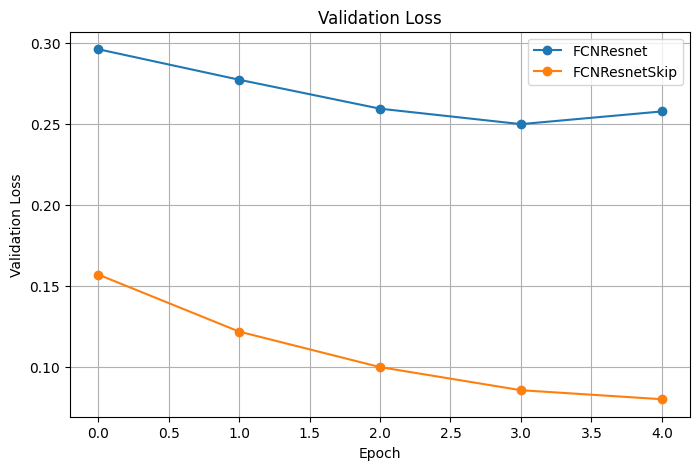

In [20]:
plt.figure(figsize=(8, 5))

plt.plot(
    fcn_val_loss["epoch"],
    fcn_val_loss["val_loss"],
    marker="o",
    label="FCNResnet",
)

plt.plot(
    skip_val_loss["epoch"],
    skip_val_loss["val_loss"],
    marker="o",
    label="FCNResnetSkip",
)

plt.xlabel("Epoch")
plt.ylabel("Validation Loss")
plt.title("Validation Loss")
plt.legend()
plt.grid(True)
plt.show()

#### Plot validation mIoU

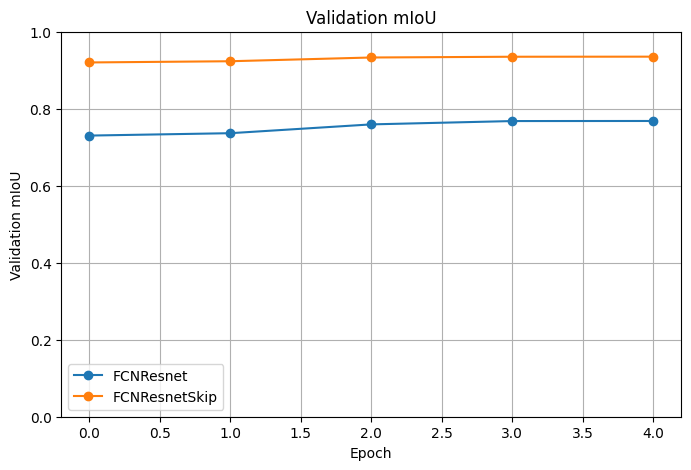

In [21]:
plt.figure(figsize=(8, 5))

plt.plot(
    fcn_val_miou["epoch"],
    fcn_val_miou["val_mIoU"],
    marker="o",
    label="FCNResnet",
)

plt.plot(
    skip_val_miou["epoch"],
    skip_val_miou["val_mIoU"],
    marker="o",
    label="FCNResnetSkip",
)

plt.xlabel("Epoch")
plt.ylabel("Validation mIoU")
plt.title("Validation mIoU")
plt.legend()
plt.grid(True)
plt.ylim(0, 1)
plt.show()

### 2.4.2 Qualitative Comparison

Visualize a few test examples side by side: **Input Image | Ground Truth | FCN Prediction | Skip Prediction**.

Look especially at forest boundaries — do the skip connections produce sharper edges?

In [22]:
# Visualize side by side:
# Input Image | Ground Truth | FCN Prediction | Skip Prediction

In [23]:
test_loader = data_module.test_dataloader()
images, masks = next(iter(test_loader))

print(images.shape)
print(masks.shape)

torch.Size([16, 10, 120, 120])
torch.Size([16, 120, 120])


In [24]:
model_fcn.eval()
model_skip.eval()

with torch.inference_mode():
    logits_fcn = model_fcn(images)
    logits_skip = model_skip(images)

# print(logits_fcn.shape)
# print(logits_skip.shape)

preds_fcn = logits_fcn.argmax(dim=1)
preds_skip = logits_skip.argmax(dim=1)

# print(preds_fcn.shape)
# print(preds_skip.shape)

In [25]:
def image_to_rgb(image):
    """
    image shape: [10, H, W]
    return shape: [H, W, 3]
    """
    image = image.cpu() * std_tensor + mean_tensor

    rgb = image[[2, 1, 0]]

    rgb = rgb.permute(1, 2, 0).numpy()

    return rgb

In [26]:
def normalize_rgb(rgb):
    normalized = rgb.copy()

    for channel in range(3):
        low, high = torch.quantile(
            torch.tensor(rgb[:, :, channel]),
            torch.tensor([0.02, 0.98]),
        )

        normalized[:, :, channel] = (
            rgb[:, :, channel] - low.item()
        ) / (high.item() - low.item())

    return normalized.clip(0, 1)

In [27]:
for j in range(images.size(0)):
    print(
        j,
        "GT:", torch.unique(masks[j]).tolist(),
        "FCN:", torch.unique(preds_fcn[j]).tolist(),
        "Skip:", torch.unique(preds_skip[j]).tolist(),
    )

0 GT: [1] FCN: [1] Skip: [1]
1 GT: [1] FCN: [1] Skip: [1]
2 GT: [1] FCN: [1] Skip: [1]
3 GT: [0, 1] FCN: [0, 1] Skip: [0, 1]
4 GT: [0, 1] FCN: [0, 1] Skip: [0, 1]
5 GT: [0, 1] FCN: [0, 1] Skip: [0, 1]
6 GT: [0, 1] FCN: [0, 1] Skip: [0, 1]
7 GT: [0, 1] FCN: [0] Skip: [0, 1]
8 GT: [0, 1] FCN: [0, 1] Skip: [0, 1]
9 GT: [1] FCN: [1] Skip: [1]
10 GT: [1] FCN: [1] Skip: [1]
11 GT: [0, 1] FCN: [0, 1] Skip: [0, 1]
12 GT: [1] FCN: [1] Skip: [1]
13 GT: [0, 1] FCN: [0, 1] Skip: [0, 1]
14 GT: [0, 1] FCN: [0, 1] Skip: [0, 1]
15 GT: [0, 1] FCN: [0, 1] Skip: [0, 1]


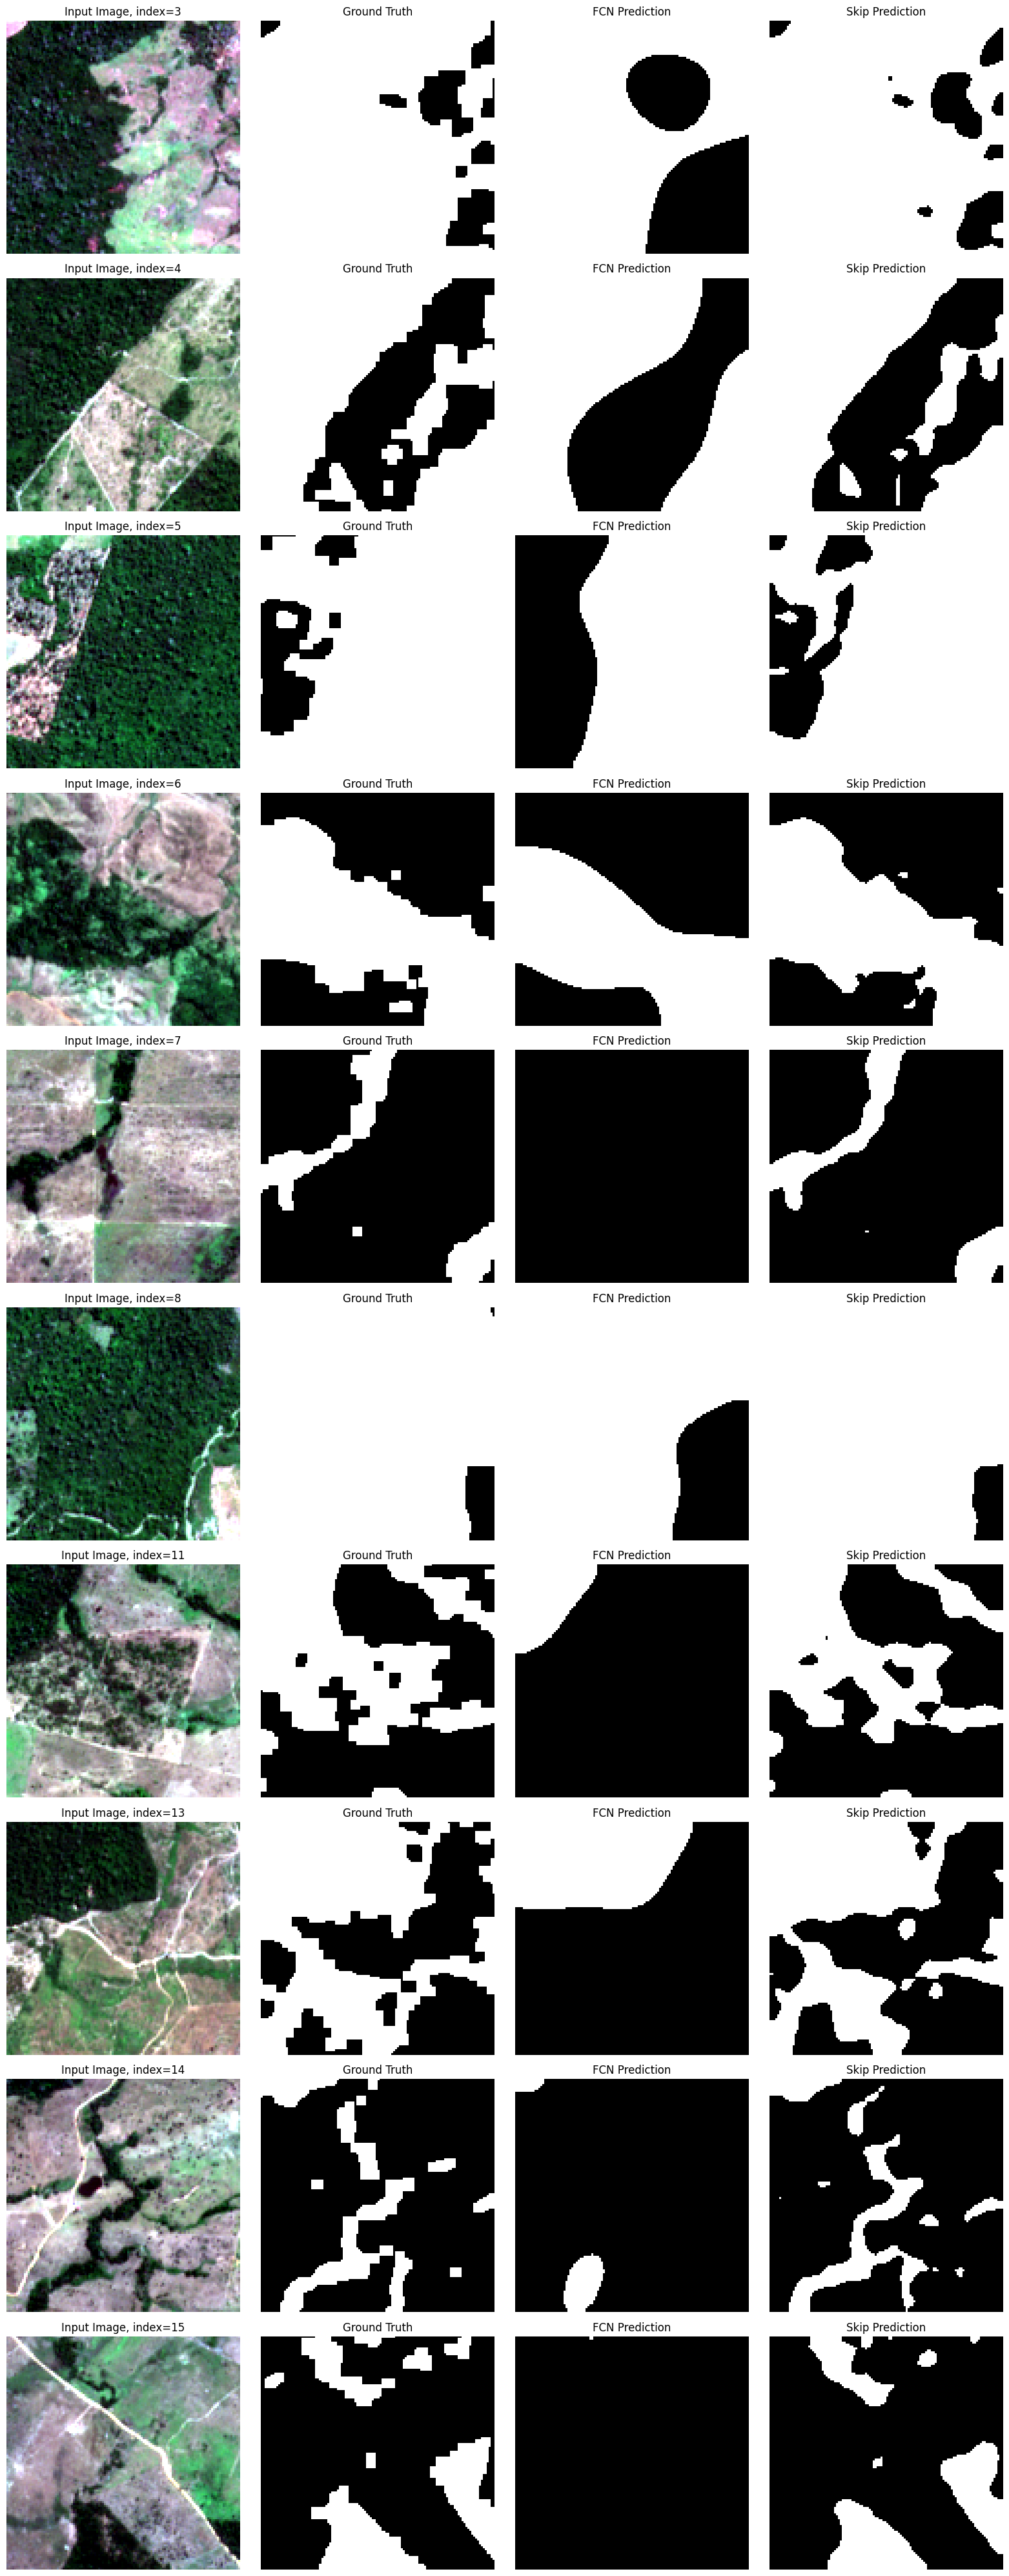

In [28]:
selected_indices = [3, 4, 5, 6, 7, 8, 11, 13, 14, 15]

fig, axes = plt.subplots(
    nrows=len(selected_indices),
    ncols=4,
    figsize=(16, 4 * len(selected_indices)),
    squeeze=False,
)

for row, j in enumerate(selected_indices):
    rgb = normalize_rgb(image_to_rgb(images[j]))

    axes[row, 0].imshow(rgb)
    axes[row, 0].set_title(f"Input Image, index={j}")

    axes[row, 1].imshow(
        masks[j].cpu(),
        cmap="gray",
        vmin=0,
        vmax=1,
    )
    axes[row, 1].set_title("Ground Truth")

    axes[row, 2].imshow(
        preds_fcn[j].cpu(),
        cmap="gray",
        vmin=0,
        vmax=1,
    )
    axes[row, 2].set_title("FCN Prediction")

    axes[row, 3].imshow(
        preds_skip[j].cpu(),
        cmap="gray",
        vmin=0,
        vmax=1,
    )
    axes[row, 3].set_title("Skip Prediction")

    for ax in axes[row]:
        ax.axis("off")

plt.tight_layout()
plt.show()

## 2.5 Reflection

In 3–5 paragraphs, describe what you observed:

- How did the two models compare quantitatively (mIoU, loss)?
- What visual differences did you notice in the predictions - especially at forest boundaries?
- Why do skip connections help? What information do they bring back that the FCN baseline lacks?

The skip model clearly outperforms the baseline model on both validation and test data. Its test mIoU increases from **0.778 to 0.935**, an absolute improvement of about **0.158**, while its test loss decreases from **0.236 to 0.085**, a reduction of about **64%**.

| Metric | Baseline FCN | Skip FCN | Difference |
|---|---:|---:|---:|
| Best validation mIoU | 0.767 | 0.933 | +0.165 |
| Test mIoU | 0.778 | 0.935 | +0.158 |
| Test loss | 0.236 | 0.085 | −64% |

The training curves show the same pattern. The baseline validation mIoU stops improving at around **0.76**, and its validation loss remains close to **0.25**. In contrast, the skip model maintains a validation mIoU above **0.92** and continues reducing its validation loss to approximately **0.09**.

Visually, the baseline FCN produces large and overly smooth prediction regions. It can often identify the general location of forest areas, but it loses narrow structures, small regions, holes, and irregular forest boundaries. The skip model follows the ground-truth shapes more closely and preserves finer spatial details, especially along curved or fragmented forest boundaries. Some small errors remain, but its predictions are consistently more precise.

Skip connections help because the deepest encoder features contain strong semantic information, such as whether an area represents forest, but lose precise spatial information after repeated downsampling. Skip connections pass higher-resolution features from earlier encoder layers directly to the decoder. These features provide edge, texture, shape, and location information that the baseline decoder lacks. The skip model therefore combines semantic understanding with detailed spatial information, resulting in more accurate segmentation boundaries.